# Analyse van Minecraft speedrun-data

In deze notebook analyseren we een dataset met Minecraft speedruns. We focussen op de **top 100 plaatsen** per categorie en visualiseren:

1. De **spreiding van de speedrun-tijden per categorie** (boxplot)
2. Een **gestapelde telling van runs per timing type en categorie** (stacked countplot)

De dataset wordt ingelezen uit `Own_Project/mce.csv`.

## 1. Data inladen en voorbereiden

We lezen de CSV in met `pandas`, en zetten de kolom `speedrun_time` om naar minuten. Daarna filteren we op de **top 100 plaatsen** (`place <= 100`).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Zorg dat grafieken in de notebook getoond worden
%matplotlib inline

# Laad het CSV-bestand
df = pd.read_csv('mce.csv')

# Converteer tijd naar minuten (uitgaande van speedrun_time in 1/100 seconden)
df['time_min'] = df['speedrun_time'] / 6000

# Selecteer top 100 plaatsen
df_top100 = df[df['place'] <= 100].copy()
df_top100.head()

,run_id,player_id,place,speedrun_time,is_verified,verify_date,submitted_date,examiner_id,timing_type,platform_id,...,level_rules,game_id,category_id,cat_name,cat_rules,player_name,player_country,player_pronouns,player_signup_date,time_min
0,zp2g6d8y,xz995g08,1,98.0,True,2022-01-30 20:40:44,2022-01-30 15:22:28,v8le49vx,realtime,nzelkr6q,...,NaN,mce,zd3vpoe2,Set Seed Any%,## Set Seed Any%\r\nReach the End Poem as quic...,Khalooody,bh,NaN,2020-01-04 11:41:15,0.016333
1,y6oovepy,x7qey508,2,100.0,True,2023-02-15 05:17:52,2023-02-13 01:47:28,xz995g08,realtime,nzelkr6q,...,NaN,mce,zd3vpoe2,Set Seed Any%,## Set Seed Any%\r\nReach the End Poem as quic...,jerrinth3glitch,us,She/Her,2020-07-05 03:44:10,0.016667
2,z0ojvx8z,xkoo9n28,3,103.0,True,2022-02-08 01:32:46,2022-02-06 02:03:06,xk4o37kj,realtime,7m6ylw9p,...,NaN,mce,zd3vpoe2,Set Seed Any%,## Set Seed Any%\r\nReach the End Poem as quic...,TrenttheN642,us,NaN,2020-01-18 17:58:36,0.017167
3,y88133ny,8vk99p5j,3,103.0,True,2022-04-21 18:02:43,2022-04-20 08:45:25,xk4o37kj,realtime,nzelkr6q,...,NaN,mce,zd3vpoe2,Set Seed Any%,## Set Seed Any%\r\nReach the End Poem as quic...,_Shrub,sa,NaN,2021-02-24 16:37:31,0.017167
4,zp99wpgm,xz995g08,5,106.0,True,2022-05-30 20:47:53,2022-05-30 18:41:16,v8le49vx,realtime,8gejn93d,...,NaN,mce,zd3vpoe2,Set Seed Any%,## Set Seed Any%\r\nReach the End Poem as quic...,Khalooody,bh,NaN,2020-01-04 11:41:15,0.017667


## 2. Spreiding van speedrun-tijden per categorie (boxplot)

In deze visualisatie tonen we de verdeling van de **speedrun-tijd in minuten** per categorie (`cat_name`) voor alleen de top 100 runs. Dit geeft inzicht in:

- Hoe breed de spreiding van tijden is binnen een categorie
- Of er categorieën zijn met duidelijk snellere of langzamere runs
- Mogelijke uitschieters (outliers)


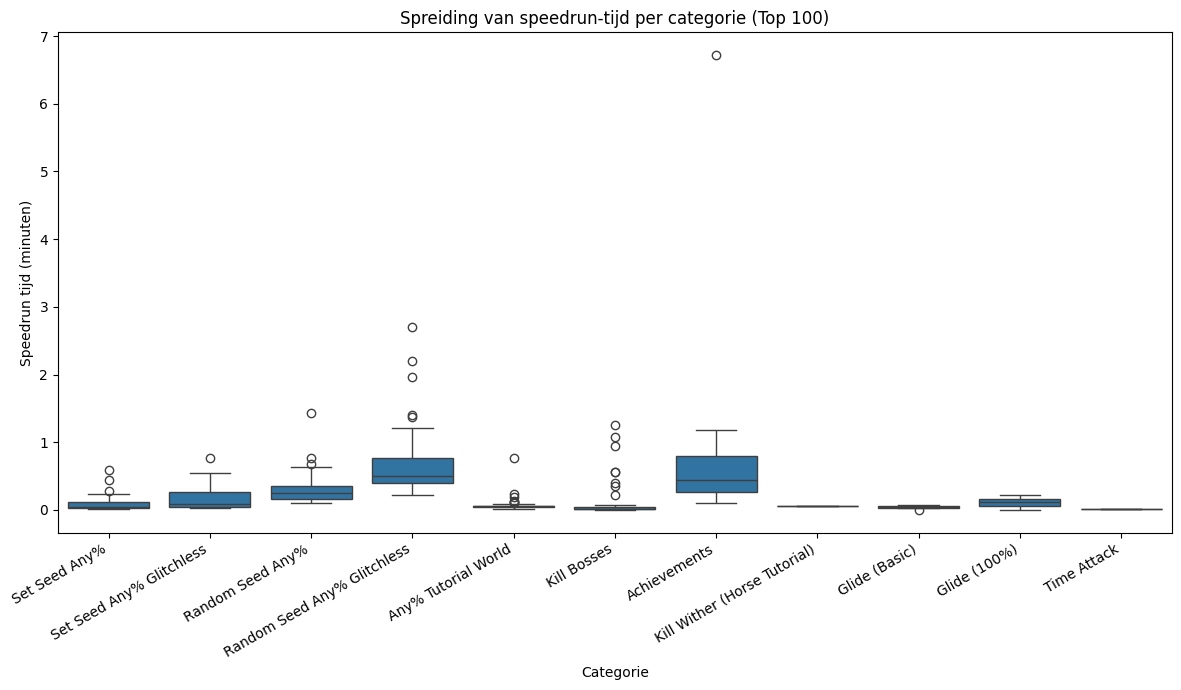

In [3]:
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_top100,
    x='cat_name',
    y='time_min'
)
plt.xlabel('Categorie')
plt.ylabel('Speedrun tijd (minuten)')
plt.title('Spreiding van speedrun-tijd per categorie (Top 100)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Interpretatie

In deze boxplot kun je per categorie zien:

- De **mediaan** (de lijn in de box): typische tijd van een run in de top 100
- De **interkwartielafstand** (de box zelf): hoe geconcentreerd of verspreid de tijden zijn
- **Uitschieters** (punten buiten de 'snorren'): runs die veel sneller of langzamer zijn dan de rest

Door categorieën te vergelijken kun je bijvoorbeeld zien welke categorieën over het algemeen sneller zijn of meer variatie in tijden hebben.

## 3. Gestapelde countplot per timing type

In deze visualisatie kijken we naar het aantal runs per categorie, opgesplitst naar `timing_type`. Dit helpt om te zien hoe de verschillende timing-methodes verdeeld zijn over de categorieën.


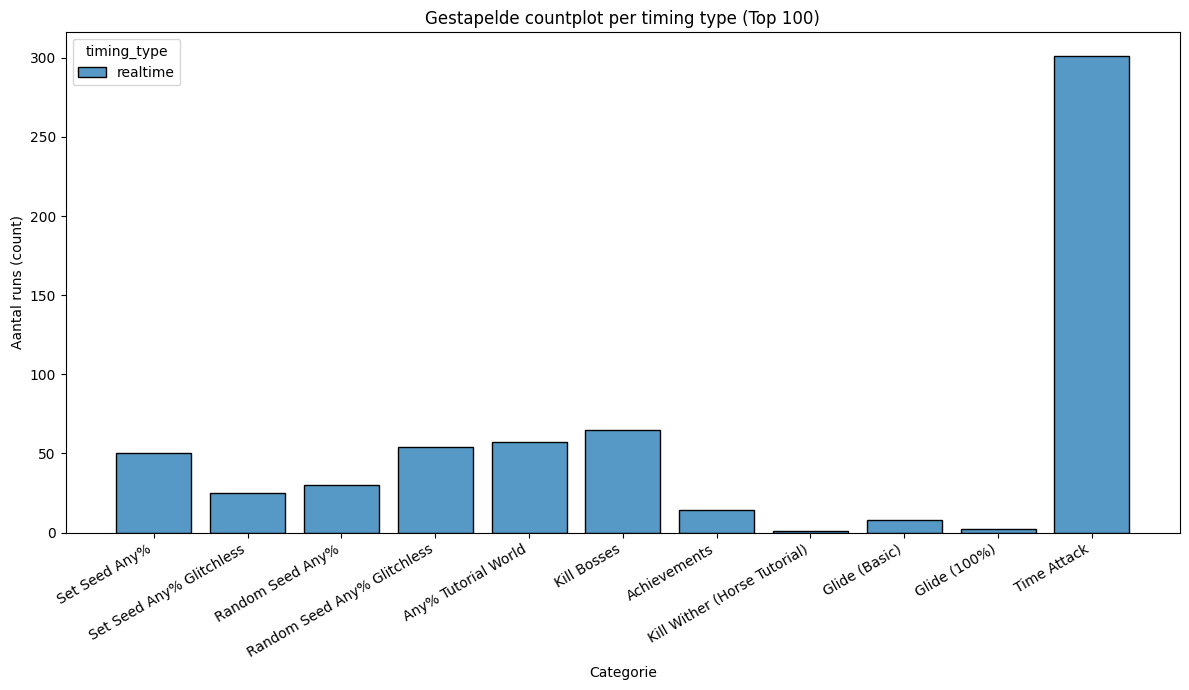

In [4]:
plt.figure(figsize=(12, 7))
sns.histplot(
    data=df_top100,
    x='cat_name',
    hue='timing_type',
    multiple='stack',
    shrink=0.8,
    discrete=True
)
plt.xlabel('Categorie')
plt.ylabel('Aantal runs (count)')
plt.title('Gestapelde countplot per timing type (Top 100)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Interpretatie

In deze gestapelde countplot kun je per categorie zien:

- **Hoeveel runs** er in de top 100 vallen (totale hoogte van de balk)
- De **verdeling per `timing_type`** binnen een categorie (opgebouwde kleuren in de balk)

Zo kun je bijvoorbeeld nagaan of bepaalde categorieën vooral met één timing-methode worden gespeeld, of dat de timing-types redelijk gelijk verdeeld zijn.

## 4. Conclusie

Met deze twee visualisaties krijg je zowel inzicht in de **prestaties per categorie** (aan de hand van de spreiding in tijden) als in de **populariteit/verdeling van timing-methodes** binnen de top 100 runs.

Mogelijke vervolgstappen:
- Vergelijken van gemiddelde tijden per categorie
- Analyse per versie van het spel of per speler
- Outliers nader onderzoeken (extreem snelle runs)
